# FIG_4 — ASWIFT FIG_3 styling

FIG_4 workflow using the ASWIFT visual conventions established in FIG_3.

Figure specifications:
- Uses a **2 × 2 layout** for the first two SWV sampling rows (**10 Hz** and **200 Hz**)
- Applies the **FIG_3 method colors, markers, line styles, and legend styling**
- Uses a **boxed method legend at the bottom**
- Uses a **log-normalized `turbo` colormap** for the raw traces in column 1
- Removes the **SNR metric column**, panel labels, and the **10 Hz / 200 Hz row labels** by default
- Plots **all finite normalized-signal points** by default; poor/outlying points are no longer hidden
- Adds editable `top_normalized_signal_ylim` and `bottom_normalized_signal_ylim` ranges so the top and bottom normalized-signal panels can clip independently
- Keeps the old SD > mean filtering option available through `filter_bad_linear_means=True`, but the default is now `False`
- Tightens the **symlog concentration axis** so the 0-concentration point sits more naturally next to the first nonzero concentration
- Adds a **small left-side buffer** near 0 on the concentration axis so the zero-concentration points are not visually clipped


In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Mapping, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
from matplotlib import cm
from matplotlib.colors import BoundaryNorm, ListedColormap, LogNorm, Normalize
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


# -----------------------------
# ASWIFT-friendly plotting defaults
# -----------------------------
plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.size": 9,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.linewidth": 1.0,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.default": "it",
})


# -----------------------------
# Helpers
# -----------------------------
def lighten_color(color, amount=0.68):
    """Blend a matplotlib color toward white."""
    import matplotlib.colors as mc
    c = np.array(mc.to_rgb(color))
    return tuple((1 - amount) * c + amount * np.ones(3))


def save_figure_multi(fig, stem, out_dir="figure_exports"):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_dir / f"{stem}.png", transparent=True)
    fig.savefig(out_dir / f"{stem}.pdf", transparent=True)
    fig.savefig(out_dir / f"{stem}.svg", transparent=True)
    print(f"Saved to: {out_dir.resolve()}")


def _value_tick_label(x: float) -> str:
    x = float(x)
    if not np.isfinite(x):
        return ""
    if abs(x) >= 100:
        return f"{x:.0f}"
    if abs(x) >= 10:
        return f"{x:.1f}".rstrip("0").rstrip(".")
    return f"{x:.2f}".rstrip("0").rstrip(".")

def _hour_tick_label(x: float) -> str:
    return _value_tick_label(x)


def _select_colorbar_ticks(values, max_ticks: int = 4) -> np.ndarray:
    finite = np.asarray(values, dtype=float)
    finite = finite[np.isfinite(finite)]
    if finite.size == 0:
        return np.array([], dtype=float)
    finite = np.unique(np.sort(finite))
    if finite.size <= max_ticks:
        return finite
    idx = np.linspace(0, finite.size - 1, max_ticks)
    idx = np.unique(np.round(idx).astype(int))
    return finite[idx]



def _add_inset_colorbar(
    fig,
    ax,
    mappable,
    title="Time (h)",
    tick_values=None,
    tick_labels=None,
    *,
    width="6.2%",          # larger colorbar thickness
    height="54%",          # larger colorbar length
    loc="upper right",
    borderpad=0.75,        # smaller = closer to the corner / more over the data
    tick_fontsize=10.5,    # tick-label font size
    title_fontsize=10.8,   # colorbar title font size
    tick_width=1.0,
    tick_length=3.2,
    tick_pad=2.0,
    title_pad=6.0,
    title_x=0.5,
    title_ha="center",
    facecolor="white",
    face_alpha=0.88,
    zorder=1000,
):
    """Inset colorbar drawn above the data with a light text/background mask."""
    cax = inset_axes(
        ax,
        width=width,
        height=height,
        loc=loc,
        borderpad=borderpad,
    )
    cax.set_zorder(zorder)
    cax.set_facecolor(facecolor)
    cax.patch.set_alpha(face_alpha)

    cbar = fig.colorbar(mappable, cax=cax)
    cbar.ax.set_zorder(zorder + 1)
    cbar.ax.set_facecolor(facecolor)
    cbar.ax.patch.set_alpha(face_alpha)
    cbar.ax.yaxis.set_ticks_position("left")
    cbar.ax.yaxis.set_label_position("left")
    cbar.ax.tick_params(labelsize=tick_fontsize, width=tick_width, length=tick_length, pad=tick_pad)
    cbar.ax.set_title(title, fontsize=title_fontsize, pad=title_pad, x=title_x, ha=title_ha)

    if tick_values is not None and len(tick_values):
        cbar.set_ticks(tick_values)
        if tick_labels is None:
            cbar.set_ticklabels([_value_tick_label(t) for t in tick_values])
        else:
            cbar.set_ticklabels([str(t) for t in tick_labels])

    for txt in list(cbar.ax.get_yticklabels()) + [cbar.ax.title]:
        txt.set_bbox(dict(facecolor=facecolor, alpha=face_alpha, edgecolor="none", pad=0.25))

    if hasattr(cbar, "solids") and cbar.solids is not None:
        cbar.solids.set_alpha(1.0)
    cbar.outline.set_linewidth(tick_width)
    return cbar


def _infer_time_column(df: pd.DataFrame, candidates: Sequence[str] | None = None) -> str | None:
    if candidates is None:
        candidates = (
            "time_h",
            "time_hr",
            "time_hours",
            "hours",
            "hour",
            "elapsed_hours",
            "time",
        )
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None


def _trace_times_from_df(df: pd.DataFrame, trace_nums: Sequence[int], time_col: str | None) -> np.ndarray:
    trace_nums = np.asarray(trace_nums, dtype=int)
    if time_col is None:
        # Fallback keeps the notebook runnable if an older combined CSV lacks a time column.
        return trace_nums.astype(float)

    time_h = df[time_col].to_numpy(float)
    if len(time_h) >= int(np.nanmax(trace_nums)):
        return np.asarray([time_h[n - 1] for n in trace_nums], dtype=float)

    # Fallback for truncated summary tables.
    return trace_nums.astype(float)


# -----------------------------
# Visual encoding for methods
# Matched to FIG_4 columns 2–3
# -----------------------------
METHODS = {
    "aswift": "ASWIFT",
    "poly_linear": "Polynomial",
    "plaxco_gauss": "Multi-Gaussian",
    "justine_ewd": "Extend-Wavelet",
}

METHOD_STYLE = {
    "aswift": {
        "color": "#1f77b4",
        "marker": "o",
        "linestyle": "-",
        "linewidth": 1.5,
        "markersize": 5.2,
        "offset_decades": 0.000,
        "zorder": 20.0,
    },
    "poly_linear": {
        "color": "#ff7f0e",
        "marker": "o",
        "linestyle": "-",
        "linewidth": 1.5,
        "markersize": 5.2,
        "offset_decades": 0.000,
        "zorder": 3.0,
    },
    "plaxco_gauss": {
        "color": "#2ca02c",
        "marker": "o",
        "linestyle": "-",
        "linewidth": 1.5,
        "markersize": 5.2,
        "offset_decades": 0.000,
        "zorder": 3.0,
    },
    "justine_ewd": {
        "color": "#d62728",
        "marker": "o",
        "linestyle": "-",
        "linewidth": 1.5,
        "markersize": 5.2,
        "offset_decades": 0.000,
        "zorder": 3.0,
    },
}


def _plot_order_with_aswift_last(methods: Mapping[str, str]) -> list[str]:
    """Plot non-ASWIFT methods first and ASWIFT last so ASWIFT remains visually on top."""
    order = [method for method in methods if method != "aswift"]
    if "aswift" in methods:
        order.append("aswift")
    return order





In [2]:
def read_voltammogram_csv(csv_path: str | Path, channel: int = 0) -> Tuple[np.ndarray, np.ndarray]:
    """Assumes first col = voltage and alternating subsequent columns are currents."""
    csv_path = Path(csv_path)
    df = (
        pd.read_csv(csv_path, skiprows=6, encoding="utf-16")
        .apply(pd.to_numeric, errors="coerce")
        .dropna()
    )
    volts = df.iloc[:, 0].astype(float).to_numpy()
    currents = df.iloc[:, 1::2].dropna(how="all").astype(float).to_numpy().T
    return volts, currents[channel]


def _langmuir(c: np.ndarray, amax: float, kd: float) -> np.ndarray:
    c = np.asarray(c, float)
    return amax * (c / (kd + c))


def _fit_langmuir(c: np.ndarray, y: np.ndarray) -> Optional[Tuple[float, float]]:
    try:
        from scipy.optimize import curve_fit
    except Exception:
        return None

    c = np.asarray(c, float)
    y = np.asarray(y, float)
    m = np.isfinite(c) & np.isfinite(y)
    c, y = c[m], y[m]
    if len(c) < 4:
        return None

    a0 = float(np.nanmax(y)) if np.any(np.isfinite(y)) else 1.0
    kd0 = float(np.nanmedian(c[c > 0])) if np.any(c > 0) else 1e-6
    bounds = ([0.0, 0.0], [np.inf, np.inf])

    try:
        popt, _ = curve_fit(_langmuir, c, y, p0=[a0, kd0], bounds=bounds, maxfev=20000)
        return float(popt[0]), float(popt[1])
    except Exception:
        return None


def _collect_signal_matrix(df: pd.DataFrame, freq_hz: int, method: str, n_channels: int = 12) -> np.ndarray:
    cols = [f"signal-{freq_hz}hz-ch{ch}-{method}" for ch in range(n_channels)]
    S = np.full((len(df), n_channels), np.nan, float)
    for j, col in enumerate(cols):
        if col in df.columns:
            S[:, j] = df[col].to_numpy(float)
    return S


def _gain_from_signal(S: np.ndarray, baseline_rows: slice) -> np.ndarray:
    """gain = signal / mean(signal_baseline), computed per channel."""
    b = np.nanmean(S[baseline_rows, :], axis=0)
    b = np.where(np.isfinite(b) & (b != 0), b, np.nan)
    return (S / b)


def _infer_trace_concentrations_uM(trace_nums: Sequence[int]) -> np.ndarray:
    conc_order_uM = np.array([0, 0.1, 0.2, 0.4, 1, 2, 4, 10, 20], dtype=float)
    block_idx = np.clip((np.asarray(trace_nums) - 1) // 5, 0, len(conc_order_uM) - 1)
    return conc_order_uM[block_idx]


def _add_symlog_zero_break_marks(
    ax,
    first_positive_tick: float,
    *,
    color: str = "black",
    linewidth: float = 1.0,
):
    """
    Draw a broken-axis cue between x=0 and the first positive tick on a symlog axis.

    The cue is rendered as a small open gap in the bottom axis spine with two
    slanted slash marks, making it visually clear that the region between 0 and
    the logarithmic concentrations is intentionally disconnected.
    """
    if not np.isfinite(first_positive_tick) or first_positive_tick <= 0:
        return

    trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)

    # Position the break in the open space between 0 and the first nonzero tick.
    x_left = 0.30 * first_positive_tick
    x_right = 0.54 * first_positive_tick

    # Remove the visible axis line in the break region.
    ax.plot(
        [x_left, x_right],
        [0, 0],
        transform=trans,
        color="white",
        linewidth=3.2,
        clip_on=False,
        solid_capstyle="butt",
        zorder=9,
    )

    # Draw two short diagonal slashes over the gap.
    x_centers = (0.37 * first_positive_tick, 0.47 * first_positive_tick)
    dx = 0.028 * first_positive_tick
    y0, y1 = -0.020, 0.032
    for xc in x_centers:
        ax.plot(
            [xc - dx, xc + dx],
            [y0, y1],
            transform=trans,
            color=color,
            linewidth=linewidth,
            clip_on=False,
            solid_capstyle="butt",
            zorder=10,
        )


def _style_concentration_axis(ax, x_all: np.ndarray, *, xlabel: bool = False):
    x_all = np.asarray(x_all, float)
    positive = np.sort(np.unique(x_all[x_all > 0]))
    xmin_pos = positive.min() if len(positive) else 1e-1
    xmax_pos = positive.max() if len(positive) else 1e1

    # Use symlog so x=0 can be shown together with logarithmically spaced
    # positive concentrations. The positive log decades remain equally spaced,
    # while the zero point is separated by a visual break marker.
    ax.set_xscale("symlog", linthresh=xmin_pos, linscale=1.0)
    ax.set_xlim(-0.14 * xmin_pos, xmax_pos * 3.00)

    # Keep the same log-style major ticks as before: 10^-1, 10^0, 10^1.
    # Only include decades that lie within the plotted concentration range.
    if len(positive):
        min_dec = int(np.floor(np.log10(xmin_pos)))
        max_dec = int(np.floor(np.log10(xmax_pos)))
        decade_ticks = [10.0 ** p for p in range(min_dec, max_dec + 1)]
        decade_ticks = [t for t in decade_ticks if xmin_pos <= t <= xmax_pos]
        if len(decade_ticks) == 0:
            decade_ticks = [xmin_pos]
        xticks = np.array([0.0] + decade_ticks, dtype=float)
        xticklabels = ["0"] + [rf"$10^{{{int(np.log10(t))}}}$" for t in decade_ticks]
    else:
        xticks = np.array([0.0])
        xticklabels = ["0"]

    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)
    ax.tick_params(which="minor", bottom=False)

    if len(positive):
        _add_symlog_zero_break_marks(ax, xmin_pos)

    if xlabel:
        ax.set_xlabel(r"Concentration, $[\mu M]$")



def _normalized_signal_stability_mask(
    gain_means: np.ndarray,
    gain_stds: np.ndarray,
    *,
    filter_bad_linear_means: bool = True,
) -> np.ndarray:
    """
    Filtering rule for the normalized-signal column.

    Historical optional filtering rule for the normalized-signal column.

    By default, the plotting code now keeps all finite points and uses axis
    limits to clip the visible range. If filtering is re-enabled, points are
    excluded if SD(normalized fitted peaks) > mean(normalized signal).
    """
    keep = np.isfinite(gain_means) & np.isfinite(gain_stds)
    if filter_bad_linear_means:
        keep &= gain_stds <= 0.5 * gain_means
    return keep


In [3]:
def _plot_trace_panel(
    ax,
    *,
    input_dir: str | Path,
    freq_hz: int,
    trace_nums: Sequence[int],
    trace_time_h: Sequence[float] | None = None,
    fig=None,
    add_time_colorbar: bool = True,
    colorbar_title: str = "Time (h)",
    colorbar_n_ticks: int = 4,
    colorbar_tick_values: Sequence[float] | None = None,
    colorbar_tick_labels: Sequence[str] | None = None,
    ch01_folder: str = "CH01",
    channel: int = 0,
    trace_cmap: str = "turbo",
    trace_log_color: bool = False,
    discrete_colorbar: bool = False,
):
    if trace_time_h is None:
        trace_color_h = np.asarray(trace_nums, dtype=float)
    else:
        trace_color_h = np.asarray(trace_time_h, dtype=float)

    if discrete_colorbar:
        unique_vals = np.unique(np.asarray(trace_color_h, dtype=float))
        unique_vals = unique_vals[np.isfinite(unique_vals)]
        unique_vals.sort()
        base_cmap = cm.get_cmap(trace_cmap, max(len(unique_vals), 2))
        colors = [base_cmap(i) for i in range(len(unique_vals))]
        cmap = ListedColormap(colors)
        boundaries = np.arange(len(unique_vals) + 1) - 0.5
        norm = BoundaryNorm(boundaries, cmap.N)
        value_to_index = {float(v): i for i, v in enumerate(unique_vals)}
    else:
        cmap = cm.get_cmap(trace_cmap)
        positive = trace_color_h[trace_color_h > 0]
        if trace_log_color and len(positive):
            vmin = float(np.nanmin(positive))
            vmax = float(np.nanmax(positive))
            norm = LogNorm(vmin=vmin, vmax=vmax)
        elif np.nanmax(trace_color_h) > np.nanmin(trace_color_h):
            norm = Normalize(vmin=float(np.nanmin(trace_color_h)), vmax=float(np.nanmax(trace_color_h)))
        else:
            norm = Normalize(vmin=0.0, vmax=1.0)

    for num, time_h in zip(trace_nums, trace_color_h):
        fpath = Path(input_dir) / ch01_folder / f"{freq_hz}hz-{num:02d}.csv"
        if not fpath.exists():
            alt = Path(input_dir) / ch01_folder / f"{freq_hz}hz-{num}.csv"
            if alt.exists():
                fpath = alt
            else:
                print(f"SKIP missing trace: {fpath}")
                continue

        v, i = read_voltammogram_csv(fpath, channel=channel)

        if discrete_colorbar:
            color_index = value_to_index[float(time_h)]
            plot_color = cmap(color_index)
        else:
            color_val = float(time_h)
            if isinstance(norm, LogNorm) and color_val <= 0:
                color_val = float(norm.vmin)
            plot_color = cmap(norm(color_val))

        ax.plot(v, i, color=plot_color, linewidth=1.0, alpha=0.95)

    if fig is not None and add_time_colorbar:
        sm = cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        tick_values = colorbar_tick_values
        tick_labels = colorbar_tick_labels
        if discrete_colorbar:
            tick_values = np.arange(len(unique_vals)) if tick_values is None else tick_values
            if tick_labels is None:
                tick_labels = [_value_tick_label(v) for v in unique_vals]
        else:
            if tick_values is None:
                tick_values = _select_colorbar_ticks(trace_color_h, max_ticks=colorbar_n_ticks)
        _add_inset_colorbar(
            fig, ax, sm, title=colorbar_title, tick_values=tick_values, tick_labels=tick_labels
        )

    ax.set_ylabel(fr"Current, $\mu A$ ({freq_hz} Hz)")
    ax.set_xlabel(r"Potential, $V$")

def _compute_gain_stats(
    df: pd.DataFrame,
    *,
    freq_hz: int,
    methods: Mapping[str, str],
    n_channels: int = 12,
    n_first: int = 45,
    baseline_n: int = 5,
    conc_column: str = "concentration",
    conc_in_uM: bool = True,
    plot_gain_as_percent: bool = False,
    filter_bad_linear_means: bool = False,
) -> tuple[np.ndarray, dict[str, dict[str, np.ndarray]]]:
    """Compute concentration-binned normalized signal mean and block/channel SD."""
    conc = df[conc_column].to_numpy(float)[:n_first]
    if conc_in_uM:
        conc = conc.astype(float)

    uniq_conc = np.unique(conc)
    uniq_conc.sort()
    row_idx_by_conc = {c: np.where(conc == c)[0] for c in uniq_conc}

    baseline_rows = slice(0, baseline_n)
    gain_scale = 100.0 if plot_gain_as_percent else 1.0

    stats: dict[str, dict[str, np.ndarray]] = {}

    for method in methods:
        S = _collect_signal_matrix(df.iloc[:n_first], freq_hz=freq_hz, method=method, n_channels=n_channels)
        S_norm = _gain_from_signal(S, baseline_rows=baseline_rows)

        gain_means = []
        gain_stds = []

        for c in uniq_conc:
            ridx = row_idx_by_conc[c]
            svals = S_norm[ridx, :].reshape(-1)
            svals = svals[np.isfinite(svals)]
            gain_means.append(float(np.nanmean(svals)) if len(svals) else np.nan)
            gain_stds.append(float(np.nanstd(svals, ddof=1)) if len(svals) > 1 else np.nan)

        gain_means = np.asarray(gain_means, float) * gain_scale
        gain_stds = np.asarray(gain_stds, float) * gain_scale

        st = METHOD_STYLE[method]
        x = uniq_conc.astype(float)
        xplot = x.copy()
        pos = xplot > 0
        xplot[pos] *= 10 ** st["offset_decades"]

        keep = _normalized_signal_stability_mask(
            gain_means,
            gain_stds,
            filter_bad_linear_means=filter_bad_linear_means,
        )

        stats[method] = {
            "x": x,
            "xplot": xplot,
            "mean": gain_means,
            "std": gain_stds,
            "keep": keep,
        }

    return uniq_conc, stats


def _plot_gain_row(
    ax_gain,
    *,
    df: pd.DataFrame,
    freq_hz: int,
    methods: Mapping[str, str],
    n_channels: int = 12,
    n_first: int = 45,
    baseline_n: int = 5,
    conc_column: str = "concentration",
    conc_in_uM: bool = True,
    plot_gain_as_percent: bool = False,
    fit_langmuir: bool = False,
    use_symlog_gain: bool = False,
    gain_symlog_linthresh: float = 5.0,
    filter_bad_linear_means: bool = False,
    normalized_signal_ylim: Optional[Tuple[float | None, float | None]] = None,
    show_uncertainty: bool = False,
    other_methods_alpha: float = 0.55,
    aswift_alpha: float = 1.0,
):
    uniq_conc, stats = _compute_gain_stats(
        df,
        freq_hz=freq_hz,
        methods=methods,
        n_channels=n_channels,
        n_first=n_first,
        baseline_n=baseline_n,
        conc_column=conc_column,
        conc_in_uM=conc_in_uM,
        plot_gain_as_percent=plot_gain_as_percent,
        filter_bad_linear_means=filter_bad_linear_means,
    )

    for method in _plot_order_with_aswift_last(methods):
        st = METHOD_STYLE[method]
        color = st["color"]
        lighter = lighten_color(color, amount=0.68)
        alpha = aswift_alpha if method == "aswift" else other_methods_alpha
        zorder = st.get("zorder", 3.0)

        x = stats[method]["x"]
        xplot = stats[method]["xplot"]
        y_gain = stats[method]["mean"]
        yerr_gain = stats[method]["std"]
        keep_gain = stats[method]["keep"]

        if show_uncertainty:
            ax_gain.fill_between(
                xplot[keep_gain],
                (y_gain - 0.70 * yerr_gain)[keep_gain],
                (y_gain + 0.70 * yerr_gain)[keep_gain],
                color=lighter,
                alpha=0.35 * alpha,
                linewidth=0,
                zorder=zorder - 1,
            )
            ax_gain.errorbar(
                xplot[keep_gain],
                y_gain[keep_gain],
                yerr=yerr_gain[keep_gain],
                fmt="none",
                ecolor=lighter,
                alpha=0.65 * alpha,
                elinewidth=1.1,
                capsize=2.3,
                capthick=1.0,
                zorder=zorder,
            )

        ax_gain.plot(
            xplot[keep_gain],
            y_gain[keep_gain],
            color=color,
            linestyle=st["linestyle"],
            linewidth=st["linewidth"],
            marker=st["marker"],
            markersize=st["markersize"],
            markerfacecolor=color,
            markeredgecolor="black",
            markeredgewidth=0.45,
            alpha=alpha,
            zorder=zorder + 1,
        )

        if fit_langmuir:
            fit_mask = keep_gain & np.isfinite(x) & (x > 0)
            if np.count_nonzero(fit_mask) >= 4:
                params = _fit_langmuir(x[fit_mask], y_gain[fit_mask])
                if params is not None:
                    amax, kd = params
                    cgrid = np.geomspace(max(x[fit_mask].min(), 1e-12), x[fit_mask].max(), 200)
                    ax_gain.plot(
                        cgrid,
                        _langmuir(cgrid, amax, kd),
                        color=color,
                        linestyle=(0, (4, 2)),
                        linewidth=1.1,
                        zorder=2.5,
                    )

    ax_gain.set_ylabel("Percent response" if plot_gain_as_percent else "Normalized Signal")

    if use_symlog_gain:
        ax_gain.set_yscale("symlog", linthresh=gain_symlog_linthresh)

    if normalized_signal_ylim is not None:
        ax_gain.set_ylim(*normalized_signal_ylim)

    _style_concentration_axis(ax_gain, uniq_conc, xlabel=True)


def _plot_gain_std_row(
    ax_std,
    *,
    df: pd.DataFrame,
    freq_hz: int,
    methods: Mapping[str, str],
    n_channels: int = 12,
    n_first: int = 45,
    baseline_n: int = 5,
    conc_column: str = "concentration",
    conc_in_uM: bool = True,
    plot_gain_as_percent: bool = False,
    filter_bad_linear_means: bool = False,
    std_log_scale: bool = True,
    std_ylim: Optional[Tuple[float | None, float | None]] = None,
    other_methods_alpha: float = 0.55,
    aswift_alpha: float = 1.0,
):
    uniq_conc, stats = _compute_gain_stats(
        df,
        freq_hz=freq_hz,
        methods=methods,
        n_channels=n_channels,
        n_first=n_first,
        baseline_n=baseline_n,
        conc_column=conc_column,
        conc_in_uM=conc_in_uM,
        plot_gain_as_percent=plot_gain_as_percent,
        filter_bad_linear_means=filter_bad_linear_means,
    )

    for method in _plot_order_with_aswift_last(methods):
        st = METHOD_STYLE[method]
        color = st["color"]
        alpha = aswift_alpha if method == "aswift" else other_methods_alpha
        zorder = st.get("zorder", 3.0)
        xplot = stats[method]["xplot"]
        y_std = stats[method]["std"]
        keep_std = np.isfinite(y_std)
        if std_log_scale:
            keep_std &= y_std > 0

        ax_std.plot(
            xplot[keep_std],
            y_std[keep_std],
            color=color,
            linestyle=st["linestyle"],
            linewidth=st["linewidth"],
            marker=st["marker"],
            markersize=st["markersize"],
            markerfacecolor=color,
            markeredgecolor="black",
            markeredgewidth=0.45,
            alpha=alpha,
            zorder=zorder + 1,
        )

    if std_log_scale:
        ax_std.set_yscale("log")

    if std_ylim is not None:
        ax_std.set_ylim(*std_ylim)

    ax_std.set_ylabel("Std. Dev.")
    _style_concentration_axis(ax_std, uniq_conc, xlabel=True)

def plot_fig_4_style(
    combined_csv: str | Path,
    input_dir: str | Path,
    *,
    freqs: Sequence[int] = (10, 200),
    methods: Mapping[str, str] = METHODS,
    ch01_folder: str = "CH01",
    trace_nums: Sequence[int] = (5, 10, 15, 20, 25, 30, 35, 40, 45),
    n_channels: int = 12,
    n_first: int = 45,
    baseline_n: int = 5,
    conc_column: str = "concentration",
    conc_in_uM: bool = True,
    plot_gain_as_percent: bool = False,
    fit_langmuir: bool = False,
    use_symlog_gain: bool = False,
    gain_symlog_linthresh: float = 5.0,
    filter_bad_linear_means: bool = False,
    normalized_signal_ylim: Optional[Tuple[float | None, float | None]] = None,
    normalized_signal_ylims: Optional[Sequence[Optional[Tuple[float | None, float | None]]]] = None,
    std_log_scale: bool = True,
    std_ylim: Optional[Tuple[float | None, float | None]] = None,
    std_ylims: Optional[Sequence[Optional[Tuple[float | None, float | None]]]] = None,
    show_normalized_signal_uncertainty: bool = False,
    other_methods_alpha: float = 0.55,
    aswift_alpha: float = 1.0,
    trace_cmap: str = "turbo",
    trace_log_color: bool = False,
    time_column_candidates: Sequence[str] = (
        "time_h", "time_hr", "time_hours", "hours", "hour", "elapsed_hours", "time"
    ),
    add_panel_labels: bool = False,
    show_row_frequency_labels: bool = False,
    save_stem: str | None = None,
):
    if len(freqs) != 2:
        raise ValueError("This ASWIFT FIG_4 layout expects exactly two rows / frequencies, e.g. freqs=(10, 200).")

    combined_csv = Path(combined_csv)
    input_dir = Path(input_dir)
    df = pd.read_csv(combined_csv)

    if conc_column not in df.columns:
        raise ValueError(f"Expected '{conc_column}' in {combined_csv}")

    trace_time_h = _trace_times_from_df(df, trace_nums, conc_column)

    if normalized_signal_ylims is not None and len(normalized_signal_ylims) != len(freqs):
        raise ValueError(
            "normalized_signal_ylims must have one entry per frequency / row, "
            f"but got {len(normalized_signal_ylims)} entries for {len(freqs)} rows."
        )
    if std_ylims is not None and len(std_ylims) != len(freqs):
        raise ValueError(
            "std_ylims must have one entry per frequency / row, "
            f"but got {len(std_ylims)} entries for {len(freqs)} rows."
        )

    fig, axes = plt.subplots(2, 3, figsize=(10.2, 6.6), sharex=False)

    for row, freq_hz in enumerate(freqs):
        row_normalized_signal_ylim = (
            normalized_signal_ylims[row]
            if normalized_signal_ylims is not None
            else normalized_signal_ylim
        )
        row_std_ylim = (
            std_ylims[row]
            if std_ylims is not None
            else std_ylim
        )

        _plot_trace_panel(
            axes[row, 0],
            input_dir=input_dir,
            freq_hz=freq_hz,
            trace_nums=trace_nums,
            trace_time_h=trace_time_h,
            fig=fig,
            add_time_colorbar=True,
            colorbar_title="",
            colorbar_tick_values=None,
            colorbar_tick_labels=None,
            ch01_folder=ch01_folder,
            trace_cmap=trace_cmap,
            trace_log_color=False,
            discrete_colorbar=True,
        )

        _plot_gain_row(
            axes[row, 1],
            df=df,
            freq_hz=freq_hz,
            methods=methods,
            n_channels=n_channels,
            n_first=n_first,
            baseline_n=baseline_n,
            conc_column=conc_column,
            conc_in_uM=conc_in_uM,
            plot_gain_as_percent=plot_gain_as_percent,
            fit_langmuir=fit_langmuir,
            use_symlog_gain=use_symlog_gain,
            gain_symlog_linthresh=gain_symlog_linthresh,
            filter_bad_linear_means=filter_bad_linear_means,
            normalized_signal_ylim=row_normalized_signal_ylim,
            show_uncertainty=show_normalized_signal_uncertainty,
            other_methods_alpha=other_methods_alpha,
            aswift_alpha=aswift_alpha,
        )

        _plot_gain_std_row(
            axes[row, 2],
            df=df,
            freq_hz=freq_hz,
            methods=methods,
            n_channels=n_channels,
            n_first=n_first,
            baseline_n=baseline_n,
            conc_column=conc_column,
            conc_in_uM=conc_in_uM,
            plot_gain_as_percent=plot_gain_as_percent,
            filter_bad_linear_means=filter_bad_linear_means,
            std_log_scale=std_log_scale,
            std_ylim=row_std_ylim,
            other_methods_alpha=other_methods_alpha,
            aswift_alpha=aswift_alpha,
        )

        if show_row_frequency_labels:
            axes[row, 0].text(
                0.03, 0.97, f"{freq_hz} Hz",
                transform=axes[row, 0].transAxes,
                ha="left", va="top",
                fontsize=10, fontweight="bold",
            )

    if add_panel_labels:
        panel_labels = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]
        for ax, label in zip(axes.ravel(), panel_labels):
            ax.text(
                -0.22, 1.06, label,
                transform=ax.transAxes,
                fontsize=14,
                fontweight="bold",
                va="top",
                ha="left",
            )

    method_handles = []
    for method_key, method_label in methods.items():
        st = METHOD_STYLE[method_key]
        method_handles.append(
            Line2D(
                [0], [0],
                color=st["color"],
                linestyle=st["linestyle"],
                linewidth=st["linewidth"],
                marker=st["marker"],
                markersize=st["markersize"],
                markerfacecolor=st["color"],
                markeredgecolor="black",
                markeredgewidth=0.45,
                label=method_label,
            )
        )

    fig.legend(
        handles=method_handles,
        loc="lower center",
        ncol=len(method_handles),
        frameon=True,
        fancybox=False,
        edgecolor="black",
        facecolor="white",
        bbox_to_anchor=(0.5, 0.02),
        handlelength=2.2,
        columnspacing=1.8,
        borderpad=0.8,
    )

    fig.subplots_adjust(top=0.96, bottom=0.20, left=0.06, right=0.98, wspace=0.34, hspace=0.32)

    if save_stem is not None:
        save_figure_multi(fig, save_stem)

    return fig, axes


/var/folders/j4/r_tjgvn15y16clpqr_5grrbc0000gn/T/ipykernel_14487/2882920235.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = cm.get_cmap(trace_cmap, max(len(unique_vals), 2))
/var/folders/j4/r_tjgvn15y16clpqr_5grrbc0000gn/T/ipykernel_14487/2084753502.py:54: RuntimeWarning: Mean of empty slice
  b = np.nanmean(S[baseline_rows, :], axis=0)
/var/folders/j4/r_tjgvn15y16clpqr_5grrbc0000gn/T/ipykernel_14487/2084753502.py:54: RuntimeWarning: Mean of empty slice
  b = np.nanmean(S[baseline_rows, :], axis=0)
/var/folders/j4/r_tjgvn15y16clpqr_5grrbc0000gn/T/ipykernel_14487/2882920235.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` inste

Saved to: /Users/Max_1/PycharmProjects/aswift_figures/figures/figure_exports


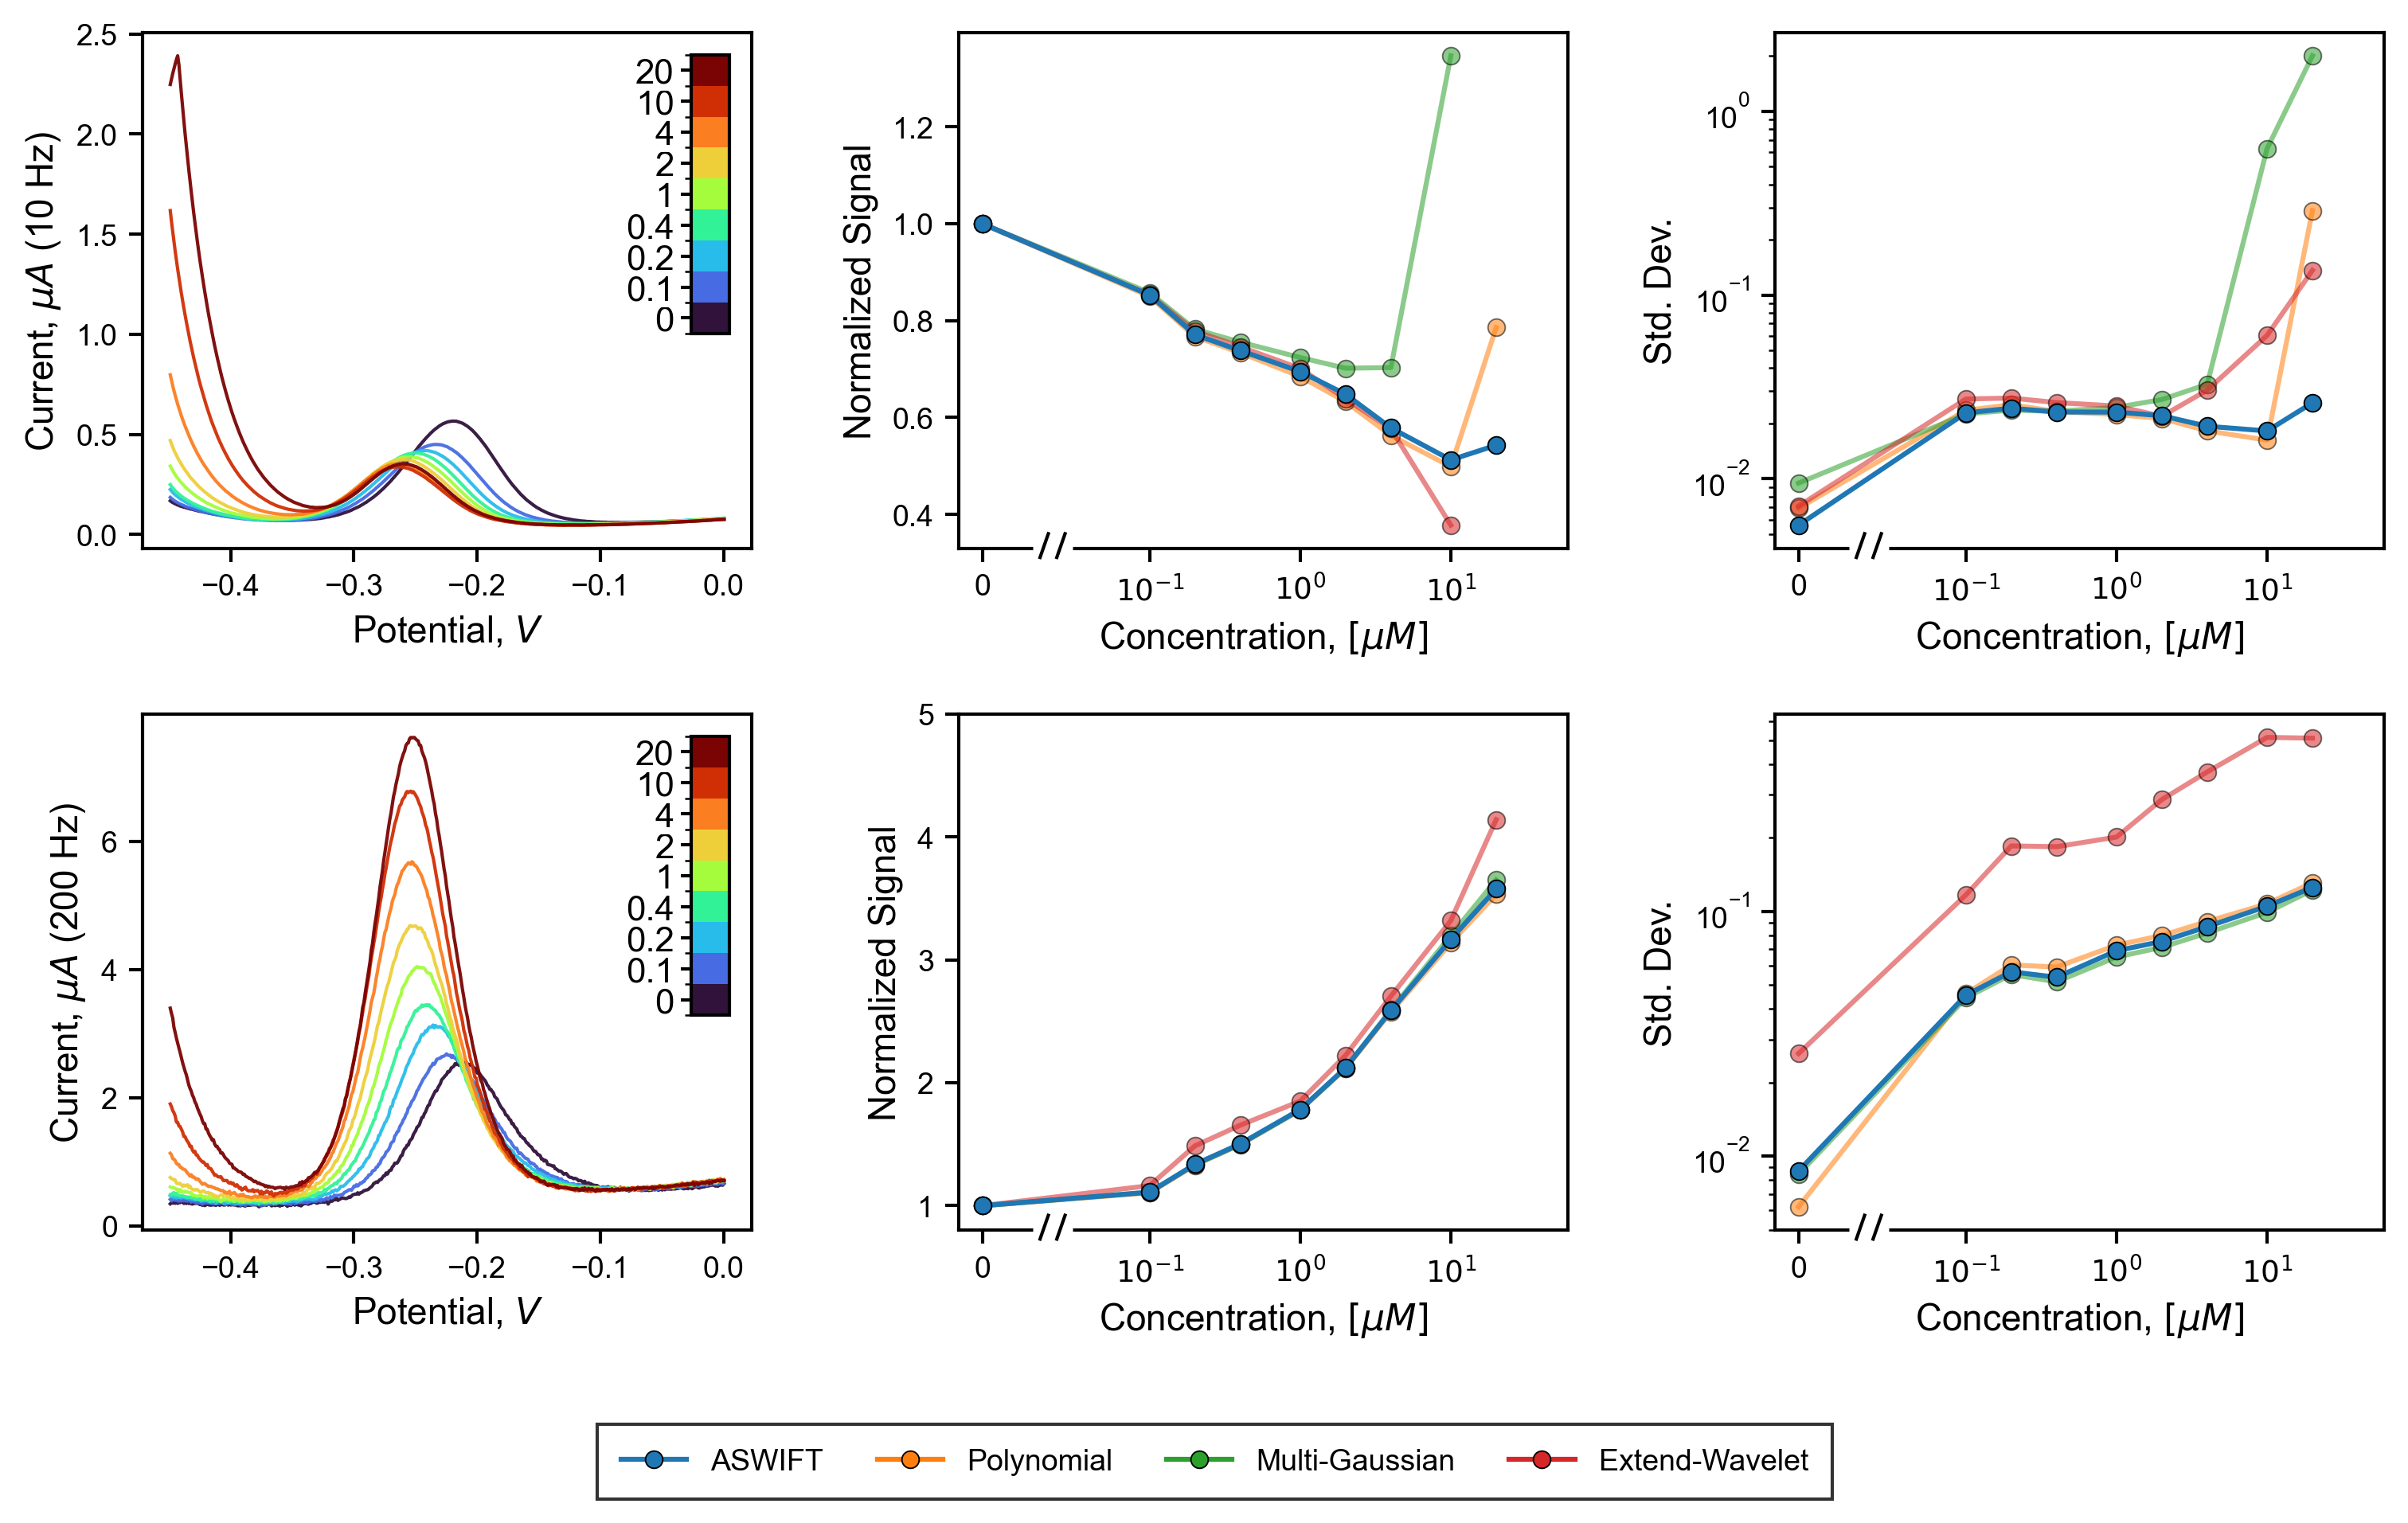

In [4]:
methods = {
    "aswift": "ASWIFT",
    "poly_linear": "Polynomial",
    "plaxco_gauss": "Multi-Gaussian",
    "justine_ewd": "Extend-Wavelet",
}

# Visible normalized-signal ranges for column 2.
# All finite points are still plotted; points outside these ranges
# are clipped at the axes boundary instead of being hidden.
# Use None for either row to autoscale that row and show the full range.
top_normalized_signal_ylim = None    # top row / 10 Hz
bottom_normalized_signal_ylim = (0.8, 5.0)  # bottom row / 200 Hz
normalized_signal_ylims = (top_normalized_signal_ylim, bottom_normalized_signal_ylim)

# Optional block-standard-deviation y-limits for the new column 3.
# With std_log_scale=True, limits must be positive.
std_ylims = (
    None,  # top row / 10 Hz
    None,  # bottom row / 200 Hz
)

fig, axes = plot_fig_4_style(
    combined_csv="/Users/Max_1/Soh Lab/echem/20260213_Dox_BC/combined_ch0.csv",
    input_dir="/Users/Max_1/Soh Lab/echem/20260213_Dox_BC",
    freqs=(10, 200),                 # only the first two rows
    methods=methods,
    fit_langmuir=False,
    use_symlog_gain=False,           # False = linear y-axis; True = symlog y-axis
    gain_symlog_linthresh=5.0,
    filter_bad_linear_means=True,   # False = do not hide high-SD / bad points
    normalized_signal_ylims=normalized_signal_ylims,
    show_normalized_signal_uncertainty=False,  # False removes column-2 error bars/shaded SD
    std_log_scale=True,                       # default: plot block SD on a log scale
    std_ylims=std_ylims,
    trace_cmap="turbo",
    trace_log_color=False,           # not used for the discrete DOX concentration colorbar
    add_panel_labels=False,
    show_row_frequency_labels=False,
    save_stem="FIG_4",
)

plt.show()
